# MentorMatch ML Project


"People struggle to find the right mentors due to lack of structured matching systems."

In [8]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn

In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns


## Upload Dataset

In [10]:
import pandas as pd

df = pd.read_csv('dataset.csv')
df.head()

,profile_id,name,email,location,headline,about,current_role,current_company,industry,years_experience,seniority_level,skills,experience,education,connections,goals,needs,can_offer,remote_preference,target_category
0,54641238e8a5986c20e095bdfbd58f9c,Brett Petersen,samantha25example.net,"Stonefurt, AK",Designer Product Building impactful solutions,Experienced professional focused on driving gr...,Data Scientist,GrowthTech,Transportation,3,mid,"['User Research', 'Microservices', 'Adobe XD',...","[{'title': 'Software Engineer', 'company': 'Ra...","[{'school': 'Berkeley', 'degree': 'MBA', 'fiel...",437,"['Mentor others', 'Lead projects']","['job opportunities', 'funding', 'partnerships']","['investment', 'technical mentorship', 'speaki...",remote,Cloud/DevOps
1,74d242dc227f39aa211913cb302cefb9,Daniel Stewart,adonovanexample.org,"West Kimberlytown, HI",Analyst Design Building impactful solutions,Strategic thinker with expertise in scaling or...,Assistant,Airbnb,E-commerce,2,entry,"['CICD', 'Sketch', 'AWS', 'TensorFlow', 'Pytho...","[{'title': 'Coordinator', 'company': 'ScaleUp'...","[{'school': 'Northwestern', 'degree': 'PhD', '...",99,"['Learn new skills', 'Get promoted']","['technical expertise', 'career guidance', 'me...","['hiring referrals', 'consulting', 'product fe...",hybrid,Data Science
2,dcaef3d5aea0edaeae6f31f65812f9da,Mary Tucker,shawn77example.com,"Jamesshire, SD",CEO Tech Building impactful solutions,Creative problem solver dedicated to creating ...,CFO,Airbnb,Transportation,15,executive,"['Spark', 'Data Science', 'Deep Learning', 'An...","[{'title': 'CTO', 'company': 'Uber', 'duration...","[{'school': 'Yale', 'degree': 'MBA', 'field': ...",4799,"['Build company', 'Advisory roles']","['clients', 'job opportunities', 'business adv...","['product feedback', 'partnership opportunitie...",onsite,Data Science
3,b466db7fe3f40bce14c91b9ad2991719,Sara Ramirez,ortizmichelleexample.org,"West Joystad, OH",Data Scientist Data Building impactful solut...,Passionate about building innovative solutions...,Product Manager,RapidGrow,Technology,6,mid,"['React', 'Sketch', 'Figma', 'R', 'Java', 'Pro...","[{'title': 'Data Scientist', 'company': 'Netfl...","[{'school': 'Penn', 'degree': 'MBA', 'field': ...",884,"['Mentor others', 'Specialize']","['funding', 'partnerships', 'technical experti...","['industry connections', 'hiring referrals', '...",hybrid,Data Science
4,e08cf08bf687933f06b5ecac3e5ef572,Andre Brown,troy00example.org,"Cunninghambury, RI",Analyst Data Building impactful solutions,Technical leader with a track record of succes...,Analyst,InnovateCo,Retail,1,entry,"['Sketch', 'PyTorch', 'Swift', 'Illustrator', ...","[{'title': 'Associate Consultant', 'company': ...","[{'school': 'Yale', 'degree': 'MBA', 'field': ...",223,"['Build network', 'Learn new skills']","['technical expertise', 'network connections',...","['technical mentorship', 'investment', 'consul...",remote,Cyber Security


## Data Preprocessing

In [11]:
import ast

df.fillna('', inplace=True)

# Convert string lists → proper text
df['skills'] = df['skills'].apply(lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else "")
df['goals'] = df['goals'].apply(lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else "")
df['needs'] = df['needs'].apply(lambda x: " ".join(ast.literal_eval(x)) if isinstance(x, str) else "")

df['combined_text'] = df['skills']
df['recommend_text'] =df['skills'] + " " + df['goals']

df[['skills', 'goals', 'needs', 'combined_text']].head()

,skills,goals,needs,combined_text
0,User Research Microservices Adobe XD UIUX Desi...,Mentor others Lead projects,job opportunities funding partnerships,User Research Microservices Adobe XD UIUX Desi...
1,CICD Sketch AWS TensorFlow Python Big Data Dat...,Learn new skills Get promoted,technical expertise career guidance mentorship,CICD Sketch AWS TensorFlow Python Big Data Dat...
2,Spark Data Science Deep Learning Angular Micro...,Build company Advisory roles,clients job opportunities business advice,Spark Data Science Deep Learning Angular Micro...
3,React Sketch Figma R Java Prototyping Scala De...,Mentor others Specialize,funding partnerships technical expertise,React Sketch Figma R Java Prototyping Scala De...
4,Sketch PyTorch Swift Illustrator Prototyping R...,Build network Learn new skills,technical expertise network connections funding,Sketch PyTorch Swift Illustrator Prototyping R...


## VISUALIZATION

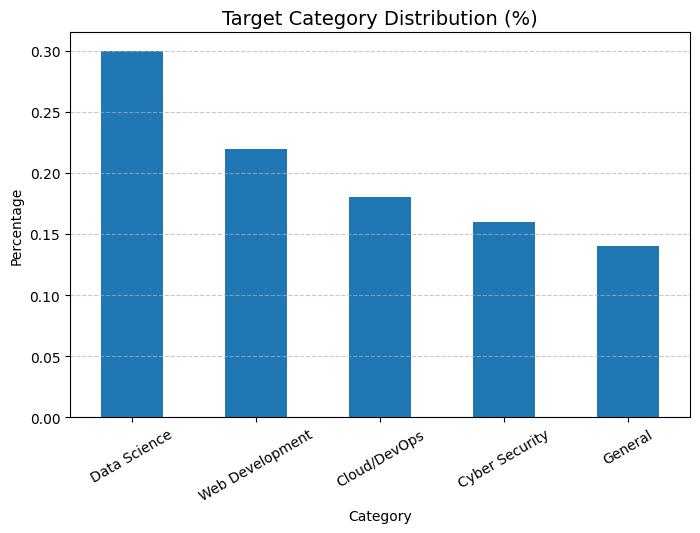

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns


plt.figure(figsize=(8,5))
df['target_category'].value_counts(normalize=True).plot(kind='bar')

plt.title("Target Category Distribution (%)", fontsize=14)
plt.ylabel("Percentage")
plt.xlabel("Category")
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## TF-IDF Feature Engineering

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder

tfidf = TfidfVectorizer(max_features=2000, ngram_range=(1,1))

X = tfidf.fit_transform(df['combined_text'])

le = LabelEncoder()
y = le.fit_transform(df['target_category'])

## Train-Test Split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y 
)

## Model Training

In [15]:
def run_model(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{name}")
    print("Accuracy:", acc)
    print("F1 Score:", f1)

    return acc, f1, y_pred


# Logistic Regression (Baseline)
lr = LogisticRegression(max_iter=300, C=0.5)
acc_lr, f1_lr, y_pred_lr = run_model("Logistic Regression", lr)


# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    class_weight='balanced'
)
acc_rf, f1_rf, y_pred_rf = run_model("Random Forest", rf)


# XGBoost
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.08,
    subsample=0.8,
    colsample_bytree=0.8
)
acc_xgb, f1_xgb, y_pred_xgb = run_model("XGBoost", xgb)





Logistic Regression
Accuracy: 0.9048
F1 Score: 0.9048007572408713

Random Forest
Accuracy: 0.9218
F1 Score: 0.9221677751374918

XGBoost
Accuracy: 0.9371
F1 Score: 0.9376827228130392


## Stacking Ensemble

In [16]:
stack_model = StackingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    final_estimator = RandomForestClassifier(max_depth=10, n_estimators=150),
    stack_method='predict_proba',
    cv=5,
    n_jobs=-1
)
acc_stack, f1_stack, y_pred_stack = run_model("Stacking", stack_model)


Stacking
Accuracy: 0.9517
F1 Score: 0.9519149748835831


## Stacking Cross - Validation

In [37]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(stack_model, X, y, cv=5, scoring='f1_weighted')

print("\nCross-Validation Results:")
print("F1 Scores for each fold:", cv_scores)
print("Mean F1 Score:", cv_scores.mean())


Cross-Validation Results:
F1 Scores for each fold: [0.95324748 0.94813527 0.94754905 0.95134821 0.95244301]
Mean F1 Score: 0.9505446043736455


## Model Evaluation

In [10]:
def evaluate(name, y_true, y_pred):
    print(f"\n{name}")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))
    print(classification_report(y_true, y_pred, zero_division=0))


In [11]:
evaluate('Logistic Regression', y_test, y_pred_lr)
evaluate('Random Forest', y_test, y_pred_rf)
evaluate('XGBoost', y_test, y_pred_xgb)
evaluate('Stacking', y_test, y_pred_stack)


Logistic Regression
Accuracy: 0.9048
F1 Score: 0.9048007572408713
              precision    recall  f1-score   support

           0       0.92      0.91      0.91      1800
           1       0.71      0.69      0.70      1600
           2       1.00      1.00      1.00      3000
           3       0.76      0.79      0.78      1400
           4       1.00      1.00      1.00      2200

    accuracy                           0.90     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.90      0.90      0.90     10000


Random Forest
Accuracy: 0.9218
F1 Score: 0.9221677751374918
              precision    recall  f1-score   support

           0       0.96      0.91      0.93      1800
           1       0.77      0.73      0.75      1600
           2       1.00      1.00      1.00      3000
           3       0.77      0.87      0.82      1400
           4       1.00      1.00      1.00      2200

    accuracy                           0.92     10000
   

## Confusion Matrix

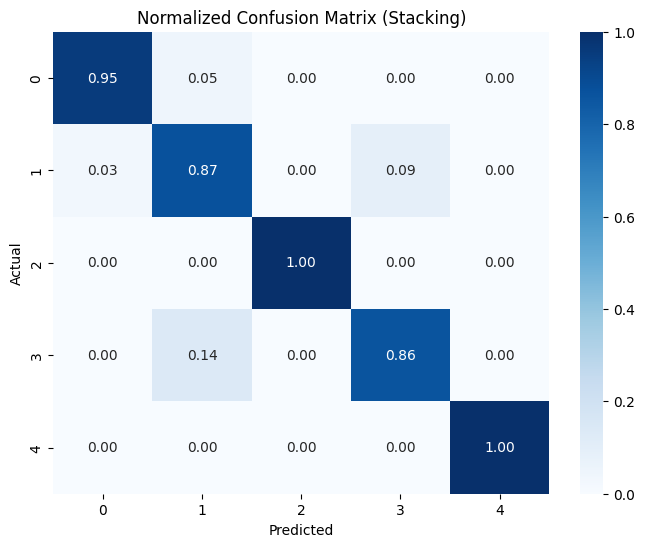

In [18]:
cm = confusion_matrix(y_test, y_pred_stack, normalize='true')

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, cmap='Blues', fmt=".2f")

plt.title("Normalized Confusion Matrix (Stacking)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

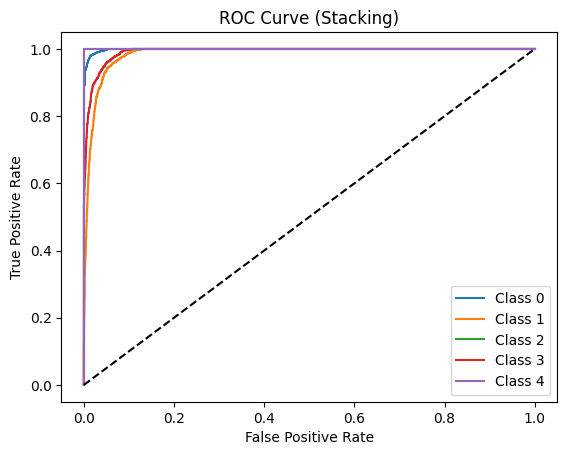

In [13]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_test_bin = label_binarize(y_test, classes=[0,1,2,3,4])
y_pred_prob = stack_model.predict_proba(X_test)

for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"Class {i}")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (Stacking)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Model Comparison Graph

<Figure size 800x500 with 0 Axes>

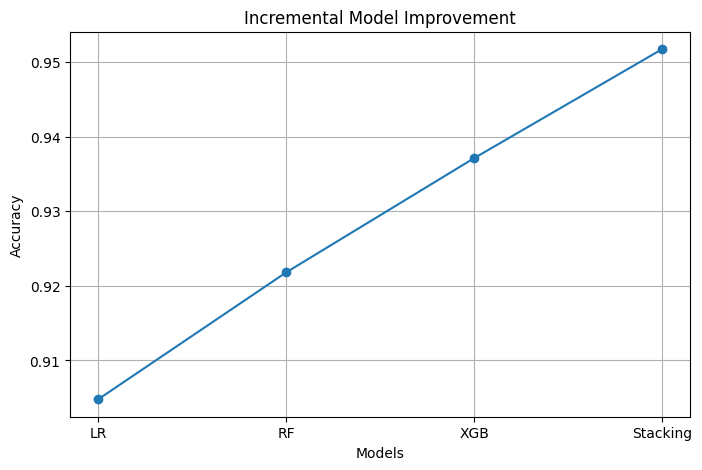

In [19]:
models = ['LR', 'RF', 'XGB', 'Stacking']
accuracy = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb),
    accuracy_score(y_test, y_pred_stack)
]

plt.figure(figsize=(8,5))
results = {
    "LR": acc_lr,
    "RF": acc_rf,
    "XGB": acc_xgb,
    "Stacking": acc_stack
}

models = list(results.keys())
accuracy = list(results.values())

plt.figure(figsize=(8,5))
plt.plot(models, accuracy, marker='o')  
plt.title("Incremental Model Improvement")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.grid()
plt.show()

In [20]:
X = tfidf.fit_transform(df['combined_text'])

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

stack_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('lr', ...), ('rf', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",RandomForestC...stimators=150)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'predict_proba'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",-1
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, def

In [24]:
from sklearn.metrics.pairwise import cosine_similarity

# ALWAYS recompute after tfidf.fit_transform
similarity_matrix = cosine_similarity(
    tfidf.transform(df['combined_text'])
)


## Recommendation System

In [52]:
def recommend_hybrid(user_index, top_n=5):
    
    user_text = df.iloc[user_index]['combined_text']
    
    user_vector = tfidf.transform([user_text])
    
    pred_category_encoded = stack_model.predict(user_vector)[0]
    pred_category = le.inverse_transform([pred_category_encoded])[0]
    
    print(f"\nPredicted Category: {pred_category}")
    
    #  Filter dataset by predicted category
    filtered_df = df[df['target_category'] == pred_category]
    filtered_indices = filtered_df.index.tolist()
    
    print(f"Total candidates considered: {len(filtered_indices)}")
    
    # Compute similarity only within filtered users
    scores = []
    for i in filtered_indices:
        sim = similarity_matrix[user_index][i]
        scores.append((i, sim))
    
    scores.sort(key=lambda x: x[1], reverse=True)
    
    #  Remove self and take top N
    recommendations = []
    for idx, score in scores:
        if idx != user_index:
            recommendations.append((idx, score))
        if len(recommendations) == top_n:
            break
    
    print("\nRecommended Mentors:\n")
    
    for i, score in recommendations:
        print(f"User {i} | Score: {score:.3f}")
        print("Skills:", df.iloc[i]['skills'])
        print("Goals:", df.iloc[i]['goals'])
        print("-"*40)

recommend_hybrid(25000)


Predicted Category: Web Development
Total candidates considered: 11000

Recommended Mentors:

User 32347 | Score: 1.000
Skills: CICD R Sketch PyTorch AWS Vue.js Ruby React Docker Operations FastAPI Django Microservices Business Development Scala
Goals: Strategic role Scale impact
----------------------------------------
User 42388 | Score: 0.664
Skills: Sketch Spark CICD PyTorch AWS TensorFlow Docker Flask FastAPI Adobe XD SQL Node.js Vue.js React Finance Terraform C Scala Express.js Operations Business Development
Goals: Advisory roles Exit strategy
----------------------------------------
User 13953 | Score: 0.659
Skills: Sketch DevOps Angular Django CICD AWS TensorFlow Python Docker Scikit-learn Google Cloud FastAPI Node.js React Microservices Scala Express.js Operations Business Development NLP
Goals: Exit strategy Build company
----------------------------------------
User 42489 | Score: 0.659
Skills: Sketch DevOps Angular Django CICD AWS TensorFlow Python Docker Scikit-learn Goo